<a href="https://colab.research.google.com/github/aayushiror/VOIS-Major-Project/blob/main/Major_Project_Seasonal_Agriculture_Performance_Analysis_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Seasonal Agriculture Performance Analysis
# Seasonal Agriculture Performance Analysis

##Major Data Analysis Project

**Domain**: Agriculture

**Project** Theme: Seasonal Agriculture Performance

**Tools**: Python, Pandas, NumPy, Matplotlib, Seaborn
# Project Goal:
Investigate how agricultural performance varies across seasons and identify meaningful patterns, trends, relationship, and differences in the available data.
   

#1. Problem Statement

Agricultural activities are influenced by seasonal variations in environmental conditions, farming practices, resource availability and economic conditions. As a result, agricultural performance may differ from one season to another.

The objective of this project is to analyze the given agricultural dataset and investigate seasonal differences in agricultural performance by identifying meaningful patterns, trends, relationships and variations within the available data.

Students should independently explore the dataset, formulate relevant analytical questions, select suitable analytical techniques and communicate findings based on evidence from the data.

#2. Project Objectives
• Understand the structure and quality of the agricultural dataset.

• Clean and prepare the data for analysis.

• Explore seasonal patterns in the dataset.

• Perform descriptive and statistical analysis.

• Investigate relationships among relevant variables.

• Compare agricultural performance across seasons and other meaningful groups.

• Use appropriate univariate, bivariate and multivariate visualizations.

• Identify significant findings from the data.

## Work Flow

1. Dataset
2. Data structure & data types
3. Missing value treatment
4. Duplicate record check
5. Descriptive / statistical analysis
6. Outlier investigation
7. Univariate analysis
8. Bivariate analysis
9. Multivariate analysis
10. Correlation analysis
11. Seasonal comparisons (with statistical testing)
12. Student-designed deep-dive analyses
13. Key insights, recommendations, limitations & conclusion

#3. Dataset

The dataset contains farm-level agricultural records covering different seasons, locations, crops, enviromental conditions, farming practices, production, costs, revenue, profit and resource usage.

In [1]:
from google.colab import drive
drive.mount("/content/drive/MyDrive/seasonal_agriculture_performance_dataset.csv")

MessageError: Error: credential propagation was unsuccessful

In [36]:
# Import required librairies
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
sns.set_theme(style="whitegrid")
pd.set_option('display.max_columns', None)
pd.set_option("display.float_format", lambda x:f"{x:,.2f}")

In [51]:
import pandas as pd
#load the dataset
df = pd.read_csv("/content/drive/MyDrive/seasonal_agriculture_performance_dataset.csv")
#top five rows
df.head()

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Irrigation_Method,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.40,24.30,69.10,5.80,7.14,32.80,75.80,61.30,91.00,Drip,242.70,4.33,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.49,55.30
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.40,25.70,78.40,5.10,5.20,32.00,82.10,35.40,121.80,Flood,271.40,6.86,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.40,49.90
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.60,23.90,56.40,10.30,5.82,8.10,118.50,51.50,117.90,Drip,162.60,6.08,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.98,33.70
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.20,29.70,65.20,6.30,5.98,23.70,138.60,55.60,115.50,Rainfed,182.20,6.39,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.16,50.60
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.60,34.10,55.20,6.50,6.90,29.30,124.10,69.00,121.40,Flood,244.90,7.61,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.83,32.30


In [ ]:
#Bottom five rows
df.tail(5)

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Irrigation_Method,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
3995,SF13996,Karnataka,Rajkot,Wheat,Kharif,4.72,865.40,27.30,51.40,6.30,7.97,27.30,104.30,44.80,94.00,Drip,271.10,5.45,0.74,0.51,2.41,22717,362917,54748,-308169,2016,1.20,45.20
3996,SF13997,Karnataka,Krishna,Chilli,Kharif,8.77,947.50,29.20,85.50,6.10,6.57,33.70,127.80,44.90,91.30,Drip,176.60,4.99,0.80,2.75,24.12,106459,496471,2567791,2071320,5351,4.51,59.70
3997,SF13998,Andhra Pradesh,Erode,Pulses,Zaid,10.47,80.00,35.40,68.50,8.60,7.25,21.10,126.70,59.90,148.00,Drip,234.70,6.27,0.99,0.62,6.49,66860,785632,433921,-351711,3392,1.91,29.20
3998,SF13999,Punjab,Warangal,Cotton,Kharif,1.73,475.00,28.20,61.70,6.40,6.11,30.50,107.50,20.70,91.00,Sprinkler,329.70,2.60,0.98,1.35,2.34,75282,153904,176160,22256,1220,1.92,50.40
3999,SF14000,Punjab,Nashik,Wheat,Kharif,3.31,984.30,25.80,77.20,5.90,6.16,35.70,137.10,92.60,145.50,Sprinkler,205.90,6.72,0.99,2.36,7.81,28812,263872,225022,-38850,1800,4.34,62.30


In [ ]:
#random sample records
df.sample(5, random_state=42)

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Irrigation_Method,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
555,SF10556,Andhra Pradesh,Nashik,Chilli,Rabi,7.94,456.80,25.30,47.70,7.60,7.10,12.90,108.00,75.80,96.50,Flood,228.20,8.51,0.87,NaN,15.64,92892,619157,1452831,833674,6146,2.54,34.40
3491,SF13492,Punjab,Warangal,Wheat,Kharif,12.44,601.90,27.20,60.20,8.30,7.66,24.30,97.80,36.70,96.00,Drip,65.90,6.88,0.77,0.94,11.69,23614,680562,276048,-404514,5818,2.01,31.80
527,SF10528,Maharashtra,Indore,Cotton,Kharif,6.35,"1,213.70",26.30,73.60,7.10,6.33,30.40,149.30,41.80,98.80,Drip,143.00,5.63,0.69,1.17,7.43,69828,441813,518822,77009,4491,1.65,52.70
3925,SF13926,Madhya Pradesh,Nashik,Wheat,Rabi,12.52,374.00,17.90,59.70,9.40,7.57,24.50,118.60,77.50,128.70,Rainfed,116.40,5.14,0.71,0.88,11.02,26649,744970,293672,-451298,3347,3.29,29.80
2989,SF12990,Gujarat,Rajkot,Chilli,Rabi,13.98,197.80,19.00,55.80,9.20,7.31,18.90,45.80,79.90,126.70,Flood,242.80,4.87,0.95,1.07,14.96,108549,994707,1623893,629186,10975,1.36,39.60


In [ ]:
#column names
print(df.columns.tolist())

['Farm_ID', 'State', 'District', 'Crop', 'Season', 'Farm_Area_Hectares', 'Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct', 'Sunlight_Hours_Day', 'Soil_pH', 'Soil_Moisture_pct', 'Nitrogen_kg_ha', 'Phosphorus_kg_ha', 'Potassium_kg_ha', 'Irrigation_Method', 'Fertilizer_kg_ha', 'Pesticide_Litre_ha', 'Seed_Quality_Score', 'Yield_Tonnes_Ha', 'Production_Tonnes', 'Market_Price_INR_Tonne', 'Total_Cost_INR', 'Revenue_INR', 'Profit_INR', 'Water_Used_m3', 'Water_Efficiency_t_per_1000m3', 'Disease_Pest_Risk_pct']


In [ ]:
# data types and non-nulls counts
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 28 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Farm_ID                        4000 non-null   object 
 1   State                          4000 non-null   object 
 2   District                       4000 non-null   object 
 3   Crop                           4000 non-null   object 
 4   Season                         4000 non-null   object 
 5   Farm_Area_Hectares             4000 non-null   float64
 6   Rainfall_mm                    3952 non-null   float64
 7   Avg_Temperature_C              4000 non-null   float64
 8   Humidity_pct                   4000 non-null   float64
 9   Sunlight_Hours_Day             4000 non-null   float64
 10  Soil_pH                        4000 non-null   float64
 11  Soil_Moisture_pct              3960 non-null   float64
 12  Nitrogen_kg_ha                 4000 non-null   f

In [ ]:
#Numerical Summary Statistics
df.describe()

,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
count,"4,000.00","3,952.00","4,000.00","4,000.00","4,000.00","4,000.00","3,960.00","4,000.00","4,000.00","4,000.00","4,000.00","4,000.00","4,000.00","3,968.00","4,000.00","4,000.00","4,000.00","4,000.00","4,000.00","4,000.00","4,000.00","4,000.00"
mean,7.89,601.15,26.82,63.21,7.32,6.70,26.51,120.25,57.78,104.76,186.04,5.07,0.83,5.27,43.25,"44,714.17","526,303.58","637,860.05","111,556.46","6,045.57",5.39,46.37
std,4.22,288.93,3.82,11.96,1.12,0.64,6.71,31.22,17.02,27.74,60.26,1.98,0.10,13.36,126.88,"30,266.16","294,419.14","636,974.71","545,081.89","5,572.94",8.84,12.42
min,0.50,80.00,16.20,25.00,3.50,5.20,8.00,40.00,15.00,30.00,40.00,0.50,0.65,0.30,0.15,"2,594.00","26,826.00","6,107.00","-1,019,223.00",128.00,0.14,5.00
25%,4.26,370.20,23.90,54.77,6.60,6.26,21.70,98.50,46.20,86.20,143.97,3.69,0.74,1.05,5.02,"21,429.25","274,577.50","207,517.25","-148,731.75","2,268.75",1.66,37.30
50%,7.89,582.00,26.90,63.00,7.30,6.69,26.40,120.10,57.50,105.10,186.25,5.12,0.83,1.74,11.77,"25,913.00","519,082.50","456,830.50","3,673.00","4,435.00",2.94,46.40
75%,11.65,834.95,29.60,71.90,8.10,7.14,31.30,141.22,69.40,123.60,227.20,6.40,0.91,2.84,24.36,"68,279.00","761,996.50","836,874.75","216,187.75","7,829.75",5.15,54.90
max,15.00,"1,395.20",39.70,95.00,11.00,8.40,47.00,220.00,120.00,200.00,400.00,12.08,1.00,101.44,"1,424.40","131,240.00","1,349,990.00","5,080,900.00","4,345,421.00","40,902.00",79.80,88.90


In [ ]:
#categorial analysis

df.describe(include="object")

,Farm_ID,State,District,Crop,Season,Irrigation_Method
count,4000,4000,4000,4000,4000,4000
unique,4000,8,10,8,3,4
top,SF13984,Andhra Pradesh,Ludhiana,Rice,Kharif,Flood
freq,1,529,427,690,1779,1310


##4. Data Quality Analysis
**Missing values and Identification**

In [ ]:
missing = df.isnull().sum().sort_values(ascending=False)
missing_percentage = (df.isnull().mean()*100).sort_values(ascending=False)

missing_summary=pd.DataFrame({
    "Missing_Count": missing,
    "Missing_Percentage": missing_percentage.round(2)
})
missing_summary[missing_summary["Missing_Count"] > 0]

,Missing_Count,Missing_Percentage
Rainfall_mm,48,1.2
Soil_Moisture_pct,40,1.0
Yield_Tonnes_Ha,32,0.8


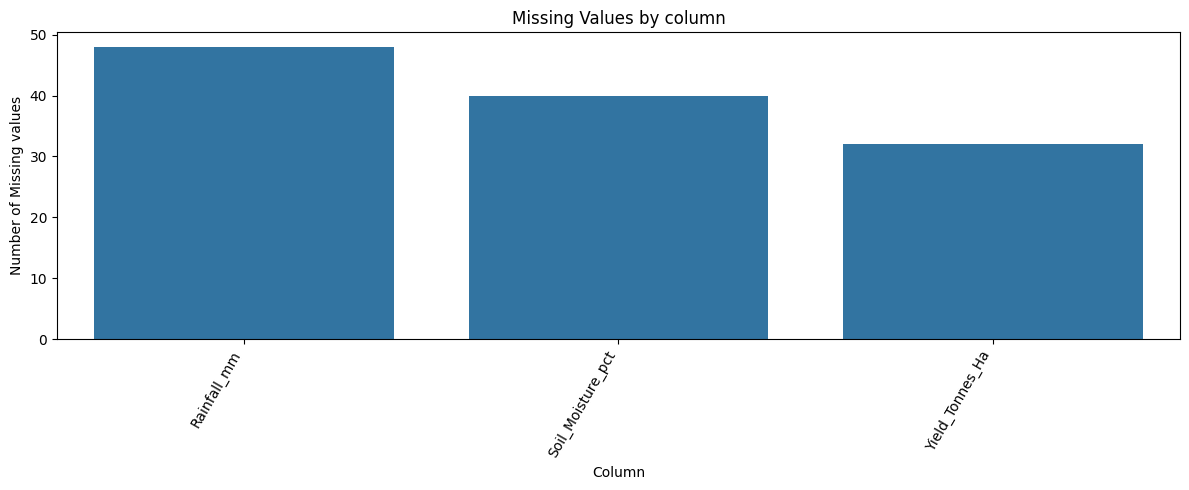

In [ ]:


#visualizing missing values

plt.figure(figsize=(12, 5))
missing_plot = missing[missing > 0]
if len(missing_plot) > 0:
    sns.barplot(x=missing_plot.index, y=missing_plot.values)
    plt.xticks(rotation=60, ha="right")
    plt.ylabel("Number of Missing values")
    plt.xlabel("Column")
    plt.title("Missing Values by column")
    plt.tight_layout ()
    plt.show()
else:
    print( "No missing values found.")

#5. Duplicate Records - Identification and Handling

In [ ]:
#duplicate records

duplicate_count = df.duplicated().sum()
print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 0


In [ ]:
# remove duplicate rows
df = df.drop_duplicates().reset_index(drop=True)
print("Shape after removing duplicates:", df.shape)

Shape after removing duplicates: (4000, 28)


#6.Descriptive Analysis



In [ ]:
# check data types again
# data types examination
df.dtypes

,0
Farm_ID,object
State,object
District,object
Crop,object
Season,object
Farm_Area_Hectares,float64
Rainfall_mm,float64
Avg_Temperature_C,float64
Humidity_pct,float64
Sunlight_Hours_Day,float64


In [ ]:
# check unique values for categorical columns

categorical_columns = df.select_dtypes(include=['object']).columns
for column in categorical_columns:
  print(f"\n{column}:")
  print(df[column].nunique(),"unique values")
  print(df[column].dropna().unique()[:20])


Farm_ID:
4000 unique values
['SF10001' 'SF10002' 'SF10003' 'SF10004' 'SF10005' 'SF10006' 'SF10007'
 'SF10008' 'SF10009' 'SF10010' 'SF10011' 'SF10012' 'SF10013' 'SF10014'
 'SF10015' 'SF10016' 'SF10017' 'SF10018' 'SF10019' 'SF10020']

State:
8 unique values
['Andhra Pradesh' 'Maharashtra' 'Telangana' 'Karnataka' 'Gujarat'
 'Tamil Nadu' 'Punjab' 'Madhya Pradesh']

District:
10 unique values
['Rajkot' 'Nalgonda' 'Warangal' 'Indore' 'Ludhiana' 'Raichur' 'Guntur'
 'Krishna' 'Nashik' 'Erode']

Crop:
8 unique values
['Wheat' 'Maize' 'Pulses' 'Rice' 'Cotton' 'Chilli' 'Groundnut' 'Sugarcane']

Season:
3 unique values
['Kharif' 'Rabi' 'Zaid']

Irrigation_Method:
4 unique values
['Drip' 'Flood' 'Rainfed' 'Sprinkler']


In [ ]:
#check missing values after duplicate removal
df.isnull().sum().sort_values(ascending=False).head(10)

,0
Rainfall_mm,48
Soil_Moisture_pct,40
Yield_Tonnes_Ha,32
Farm_ID,0
Crop,0
District,0
Farm_Area_Hectares,0
Season,0
Avg_Temperature_C,0
Humidity_pct,0


**Missing Value Treatment**

In [ ]:
numeric_columns = df.select_dtypes(include=np.number).columns
for column in numeric_columns:
  if df[column].isnull().sum() > 0:
    df[column] = df[column].median()

    print("Remaining missing values:", df.isnull().sum().sum())

Remaining missing values: 72
Remaining missing values: 32
Remaining missing values: 0


##7. Feature/Variable Review

 Review the available variables and classify them conceptually as:


*   Identifer variables
*   Categorical variables
*   Numerical variables
*   Enviromental variables
*   Operational variables
*   Production/performance variables
*   Economic variables


In [4]:
import numpy as np

#numerical and categorical columns
numeric_columns = df.select_dtypes(include=np.number).columns.tolist()
categorical_columns = df.select_dtypes(include="object").columns.tolist()

print("Numerical columns:", numeric_columns)
print("Categorical columns:", categorical_columns)

Numerical columns: ['Farm_Area_Hectares', 'Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct', 'Sunlight_Hours_Day', 'Soil_pH', 'Soil_Moisture_pct', 'Nitrogen_kg_ha', 'Phosphorus_kg_ha', 'Potassium_kg_ha', 'Fertilizer_kg_ha', 'Pesticide_Litre_ha', 'Seed_Quality_Score', 'Yield_Tonnes_Ha', 'Production_Tonnes', 'Market_Price_INR_Tonne', 'Total_Cost_INR', 'Revenue_INR', 'Profit_INR', 'Water_Used_m3', 'Water_Efficiency_t_per_1000m3', 'Disease_Pest_Risk_pct']
Categorical columns: ['Farm_ID', 'State', 'District', 'Crop', 'Season', 'Irrigation_Method']


##8. Statistical Analysis

In [5]:
#descriptive statistics

stats= df[numeric_columns].describe().T
stats["range"] = stats["max"] - stats["min"]
stats["IQR"] = stats["75%"] - stats["25%"]
stats

,count,mean,std,min,25%,50%,75%,max,range,IQR
Farm_Area_Hectares,4000.0,7.888265,4.223764,0.500,4.260,7.8950,11.65000,15.00,14.500,7.39000
Rainfall_mm,3952.0,601.152657,288.925025,80.000,370.200,582.0000,834.95000,1395.20,1315.200,464.75000
Avg_Temperature_C,4000.0,26.818900,3.818180,16.200,23.900,26.9000,29.60000,39.70,23.500,5.70000
Humidity_pct,4000.0,63.210500,11.960834,25.000,54.775,63.0000,71.90000,95.00,70.000,17.12500
Sunlight_Hours_Day,4000.0,7.323050,1.121186,3.500,6.600,7.3000,8.10000,11.00,7.500,1.50000
Soil_pH,4000.0,6.701010,0.641461,5.200,6.260,6.6900,7.14000,8.40,3.200,0.88000
Soil_Moisture_pct,3960.0,26.508232,6.712484,8.000,21.700,26.4000,31.30000,47.00,39.000,9.60000
Nitrogen_kg_ha,4000.0,120.250825,31.216452,40.000,98.500,120.1000,141.22500,220.00,180.000,42.72500
Phosphorus_kg_ha,4000.0,57.781850,17.015074,15.000,46.200,57.5000,69.40000,120.00,105.000,23.20000
Potassium_kg_ha,4000.0,104.760050,27.742681,30.000,86.200,105.1000,123.60000,200.00,170.000,37.40000


In [6]:
# median and standard deviation

statistical_summary = pd.DataFrame({
"Mean": df[numeric_columns].mean(),
"Median": df[numeric_columns].median(),
"Std_Dev": df[numeric_columns].std(),
"Min": df[numeric_columns].min(),
"Max": df[numeric_columns].max(),
})
statistical_summary

,Mean,Median,Std_Dev,Min,Max
Farm_Area_Hectares,7.888265,7.8950,4.223764,0.500,15.00
Rainfall_mm,601.152657,582.0000,288.925025,80.000,1395.20
Avg_Temperature_C,26.818900,26.9000,3.818180,16.200,39.70
Humidity_pct,63.210500,63.0000,11.960834,25.000,95.00
Sunlight_Hours_Day,7.323050,7.3000,1.121186,3.500,11.00
Soil_pH,6.701010,6.6900,0.641461,5.200,8.40
Soil_Moisture_pct,26.508232,26.4000,6.712484,8.000,47.00
Nitrogen_kg_ha,120.250825,120.1000,31.216452,40.000,220.00
Phosphorus_kg_ha,57.781850,57.5000,17.015074,15.000,120.00
Potassium_kg_ha,104.760050,105.1000,27.742681,30.000,200.00


In [7]:
#Seasonal descriptive summary

season_summary = df.groupby("Season")[numeric_columns].agg(["mean","median","std"])
season_summary

Farm_Area_Hectares                  Rainfall_mm                      \
                     mean median       std        mean  median         std   
Season                                                                       
Kharif           7.944924  8.180  4.282328  852.084205  854.75  182.552740   
Rabi             7.752207  7.680  4.179402  436.000124  430.30  175.659664   
Zaid             8.091246  8.085  4.162594  299.421784  283.30  153.980457   

       Avg_Temperature_C                  Humidity_pct  ...     Profit_INR  \
                    mean median       std         mean  ...            std   
Season                                                  ...                  
Kharif         28.454019   28.5  2.510166    71.812591  ...  611549.783883   
Rabi           23.489183   23.5  2.459561    57.893178  ...  489901.254255   
Zaid           31.042088   31.0  2.554911    52.012121  ...  436356.747261   

       Water_Used_m3                      Water_Efficiency_t_per_1000m3  \
                mean  median          std                          mean   
Season                                                                    
Kharif   6102.201237  4469.0  5670.582696                      5.891834   
Rabi     5846.987093  4292.0  5397.648066                      5.186122   
Zaid     6419.893939  4805.0  5734.619854                      4.413239   

                         Disease_Pest_Risk_pct                    
        median       std                  mean median        std  
Season                                                            
Kharif  3.2770  9.833333             54.467903   54.5  10.087931  
Rabi    2.7400  8.258037             40.482114   40.6  10.104157  
Zaid    2.3015  6.930111             38.216667   37.9   9.873938  

[3 rows x 66 columns]

##9.Univariate Analysis

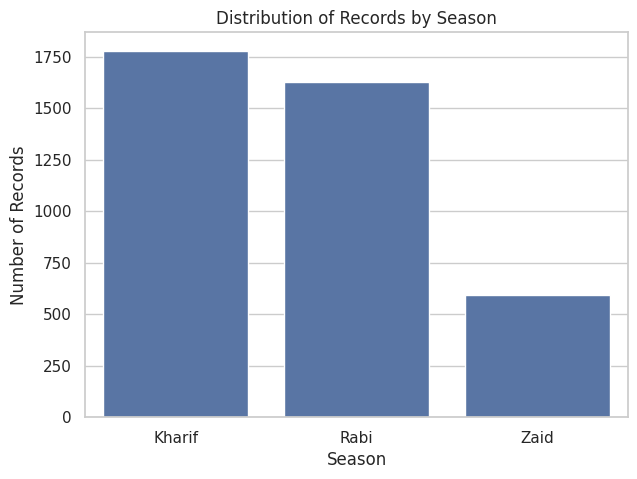

In [11]:
#Univariate: Season distribution

plt.figure(figsize=(7,5))
sns.countplot(data=df, x="Season")
plt.title("Distribution of Records by Season")
plt.xlabel("Season")
plt.ylabel("Number of Records")
plt.tight_layout
plt.show()

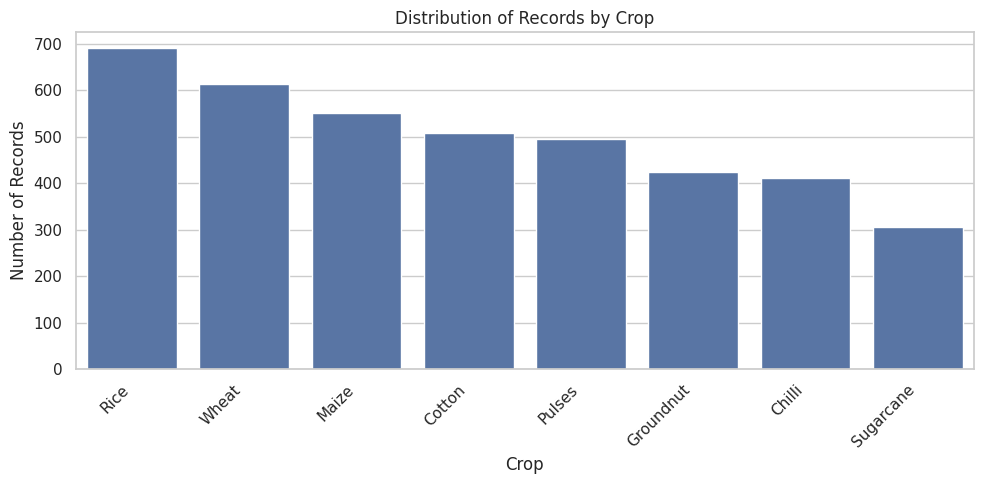

In [12]:
#Univariate: Crop distribution

plt.figure(figsize=(10, 5))
sns.countplot(data=df, x="Crop", order=df["Crop"].value_counts().index)
plt.xticks(rotation=45, ha="right")
plt.title("Distribution of Records by Crop")
plt.xlabel("Crop")
plt.ylabel("Number of Records")
plt.tight_layout()
plt.show()

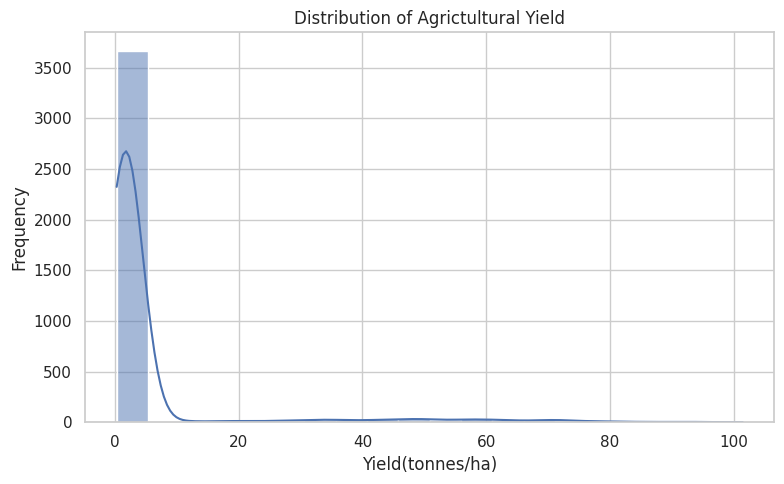

In [13]:
#Univarite: Yeild distribution

plt.figure(figsize=(8, 5))
sns.histplot(data=df, x="Yield_Tonnes_Ha", bins=20, kde=True)
plt.title("Distribution of Agrictultural Yield")
plt.xlabel("Yield(tonnes/ha)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

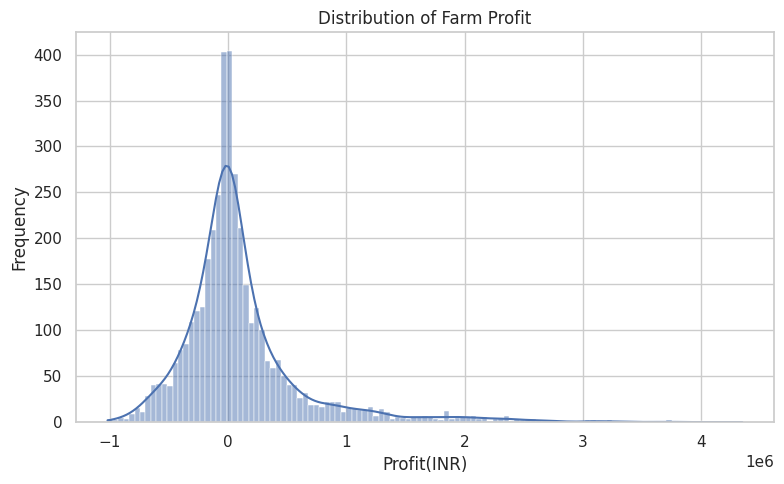

In [14]:
#Univariate: Profit distribution

plt.figure(figsize=(8, 5))
sns.histplot(data=df, x="Profit_INR", kde=True)
plt.title("Distribution of Farm Profit")
plt.xlabel("Profit(INR)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

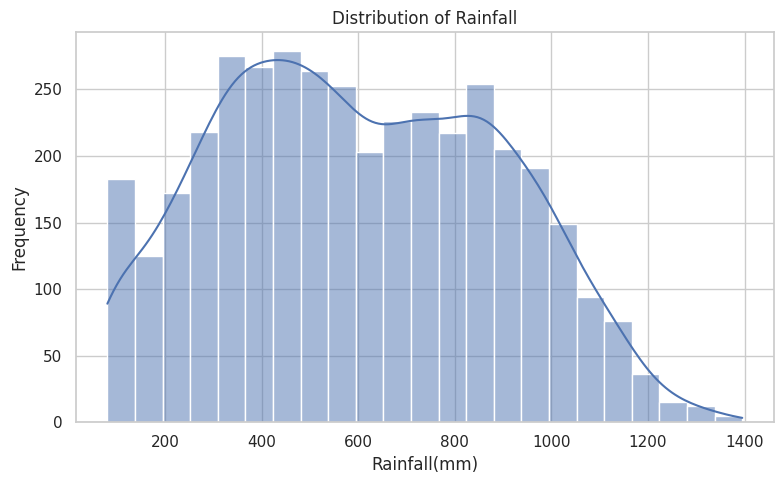

In [15]:
#Univariate: Rainfall distribution

plt.figure(figsize=(8, 5))
sns.histplot(data=df, x="Rainfall_mm", kde=True)
plt.title("Distribution of Rainfall")
plt.xlabel("Rainfall(mm)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

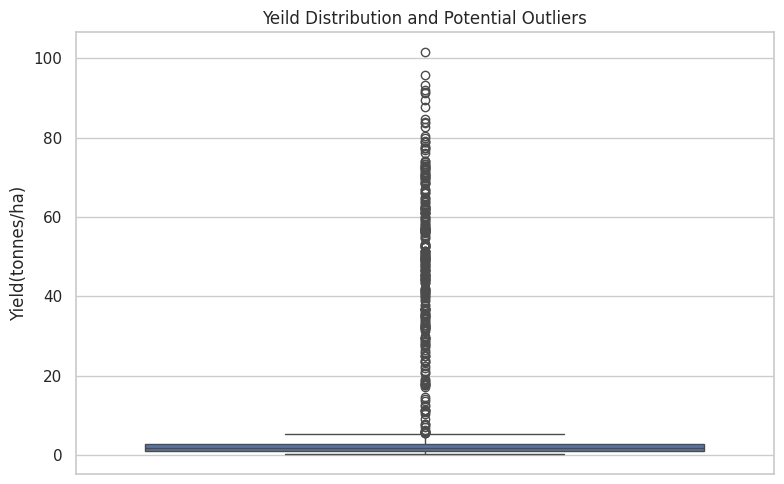

In [16]:
#Univariate: Boxplot for yeild

plt.figure(figsize=(8, 5))
sns.boxplot(data=df, y="Yield_Tonnes_Ha")
plt.title("Yeild Distribution and Potential Outliers")
plt.ylabel("Yield(tonnes/ha)")
plt.tight_layout()
plt.show()

##10. Outlier Analysis

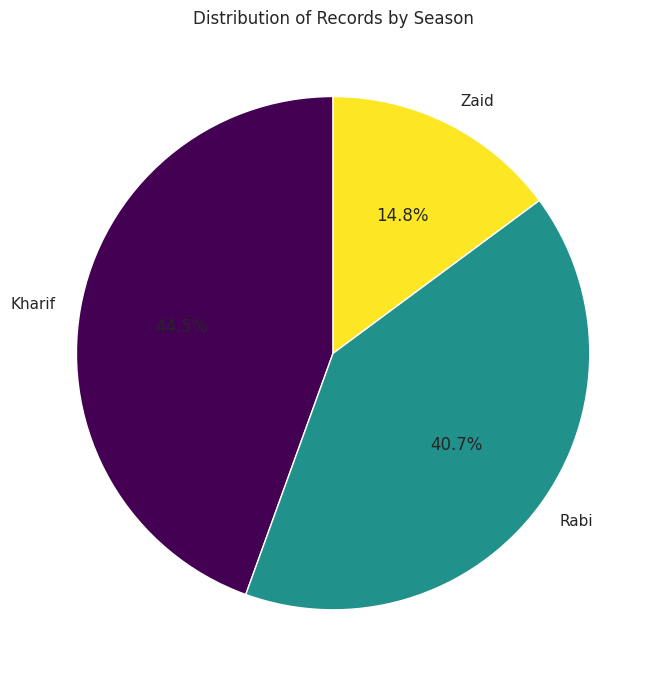

In [21]:
plt.figure(figsize=(7, 7))
df['Season'].value_counts().plot.pie(autopct='%1.1f%%', startangle=90, cmap='viridis')
plt.title('Distribution of Records by Season')
plt.ylabel('')#Hide the default 'Season' [Label] on the y-axis
plt.tight_layout()
plt.show()

In [27]:
#IQR-based outlier summary for numerical columns

outlier_summary = []
for column in numeric_columns:
  q1 = df[column].quantile(0.25)
  q3 = df[column].quantile(0.75)
  iqr = q3 - q1
  lower_bound = q1 - 1.5 * iqr
  upper_bound = q3 + 1.5 * iqr
  count = ((df[column] < lower_bound) | (df[column] > upper_bound)).sum()

  outlier_summary.append({
      "Column": column,
      "Lower_Bound": lower_bound,
      "Upper_Bound": upper_bound,
      "Outlier_Count": count,
      "Outlier_Percentage":round(count / len(df)*100, 2)
  })

outlier_summary_df = pd.DataFrame(outlier_summary).sort_values(
    "Outlier_Count", ascending=False
)
outlier_summary

[{'Column': 'Farm_Area_Hectares',
  'Lower_Bound': np.float64(-6.825000000000001),
  'Upper_Bound': np.float64(22.735),
  'Outlier_Count': np.int64(0),
  'Outlier_Percentage': np.float64(0.0)},
 {'Column': 'Rainfall_mm',
  'Lower_Bound': np.float64(-326.9250000000001),
  'Upper_Bound': np.float64(1532.0750000000003),
  'Outlier_Count': np.int64(0),
  'Outlier_Percentage': np.float64(0.0)},
 {'Column': 'Avg_Temperature_C',
  'Lower_Bound': np.float64(15.349999999999994),
  'Upper_Bound': np.float64(38.150000000000006),
  'Outlier_Count': np.int64(2),
  'Outlier_Percentage': np.float64(0.05)},
 {'Column': 'Humidity_pct',
  'Lower_Bound': np.float64(29.087499999999988),
  'Upper_Bound': np.float64(97.58750000000002),
  'Outlier_Count': np.int64(6),
  'Outlier_Percentage': np.float64(0.15)},
 {'Column': 'Sunlight_Hours_Day',
  'Lower_Bound': np.float64(4.35),
  'Upper_Bound': np.float64(10.35),
  'Outlier_Count': np.int64(26),
  'Outlier_Percentage': np.float64(0.65)},
 {'Column': 'Soil_pH

##11. Bivarite Analysis

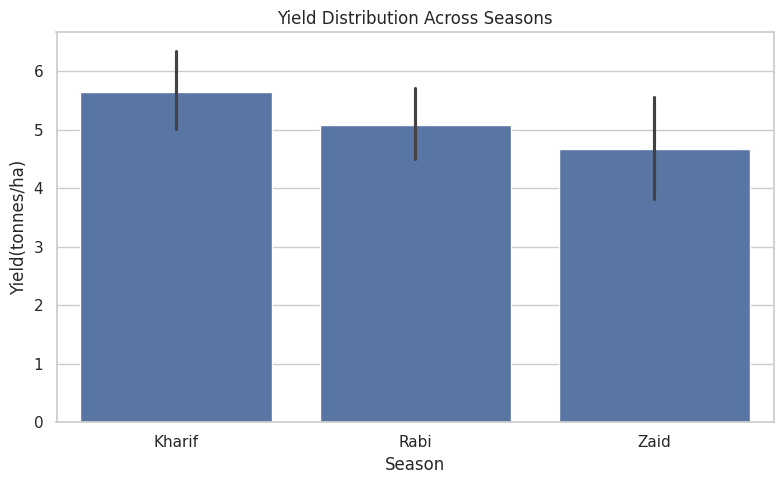

In [28]:
#Bivariate: Season vs Yield

plt.figure(figsize=(8, 5))
sns.barplot(data=df, x="Season", y="Yield_Tonnes_Ha")
plt.title("Yield Distribution Across Seasons")
plt.xlabel("Season")
plt.ylabel("Yield(tonnes/ha)")
plt.tight_layout()
plt.show()

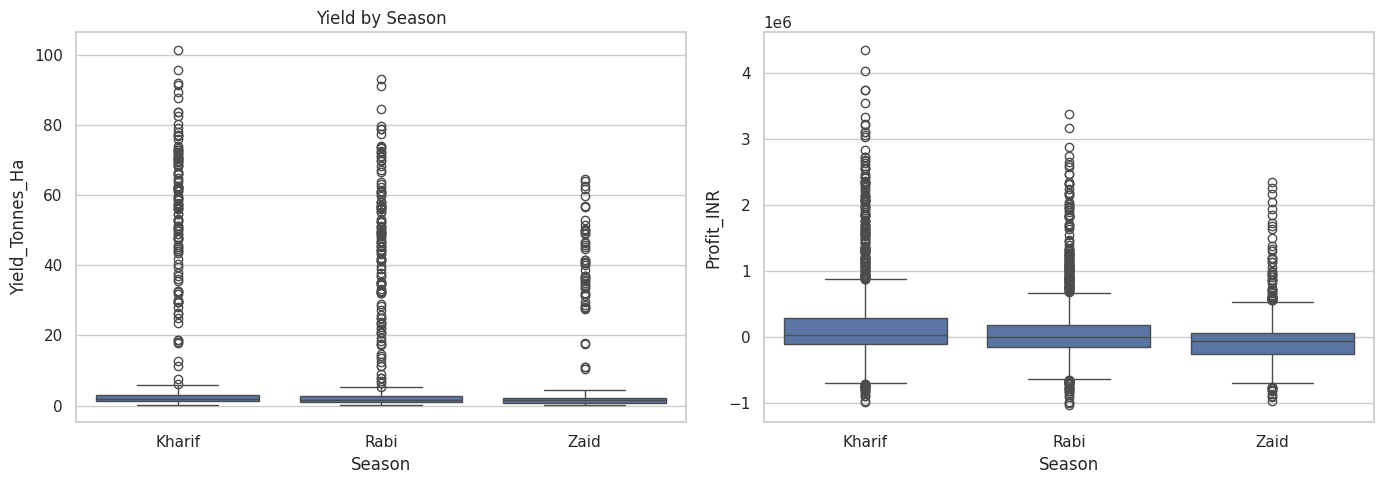

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
season_order = ['Kharif', 'Rabi', 'Zaid']
sns.boxplot(data=df, x='Season', y='Yield_Tonnes_Ha', order=season_order, ax=axes[0])
axes[0].set_title('Yield by Season')
sns.boxplot(data=df, x='Season', y='Profit_INR')
plt.tight_layout()
plt.show()

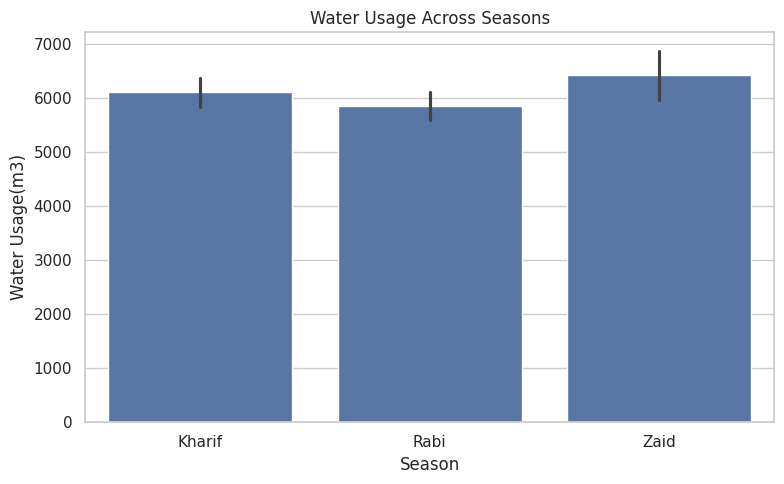

In [43]:
#Bivariate: Season vs Water Usage

plt.figure(figsize=(8, 5))
sns.barplot(data=df, x="Season", y="Water_Used_m3")
plt.title("Water Usage Across Seasons")
plt.xlabel("Season")
plt.ylabel("Water Usage(m3)")
plt.tight_layout()
plt.show()


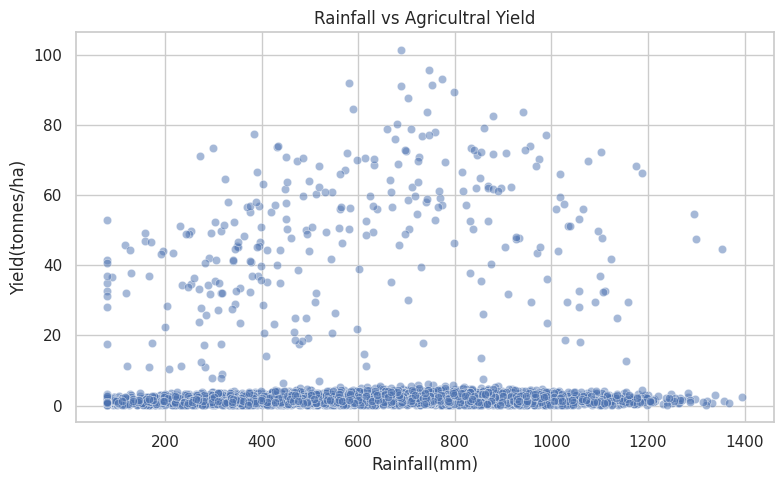

In [39]:
#Bivariate: Ranifall vs Yield

plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x="Rainfall_mm", y="Yield_Tonnes_Ha", alpha=0.5)
plt.title("Rainfall vs Agricultral Yield")
plt.xlabel("Rainfall(mm)")
plt.ylabel("Yield(tonnes/ha)")
plt.tight_layout()
plt.show()

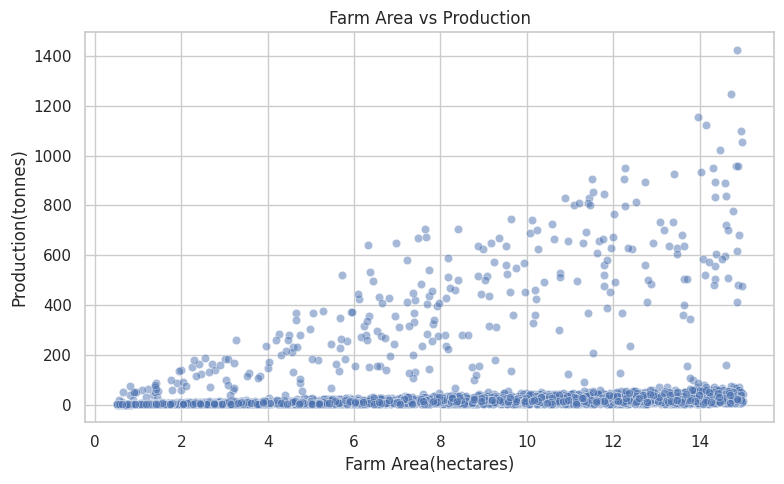

In [46]:
#Bivariate: Farm area vs Production

plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x="Farm_Area_Hectares", y="Production_Tonnes", alpha=0.5)
plt.title("Farm Area vs Production")
plt.xlabel("Farm Area(hectares)")
plt.ylabel("Production(tonnes)")
plt.tight_layout()
plt.show()

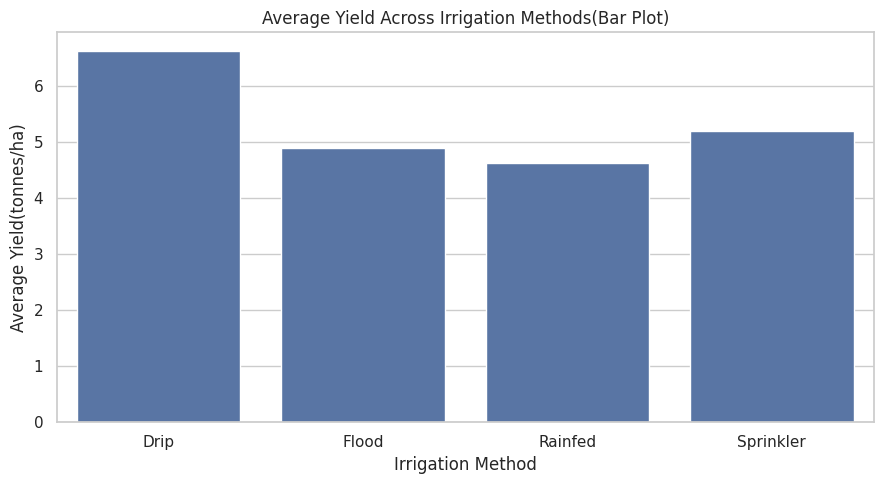

In [47]:
plt.figure(figsize=(9,5))
sns.barplot(data=df, x="Irrigation_Method", y="Yield_Tonnes_Ha", errorbar=None)
plt.title("Average Yield Across Irrigation Methods(Bar Plot)")
plt.xlabel("Irrigation Method")
plt.ylabel("Average Yield(tonnes/ha)")
plt.tight_layout()
plt.show()

##12. Multivariate Analysis

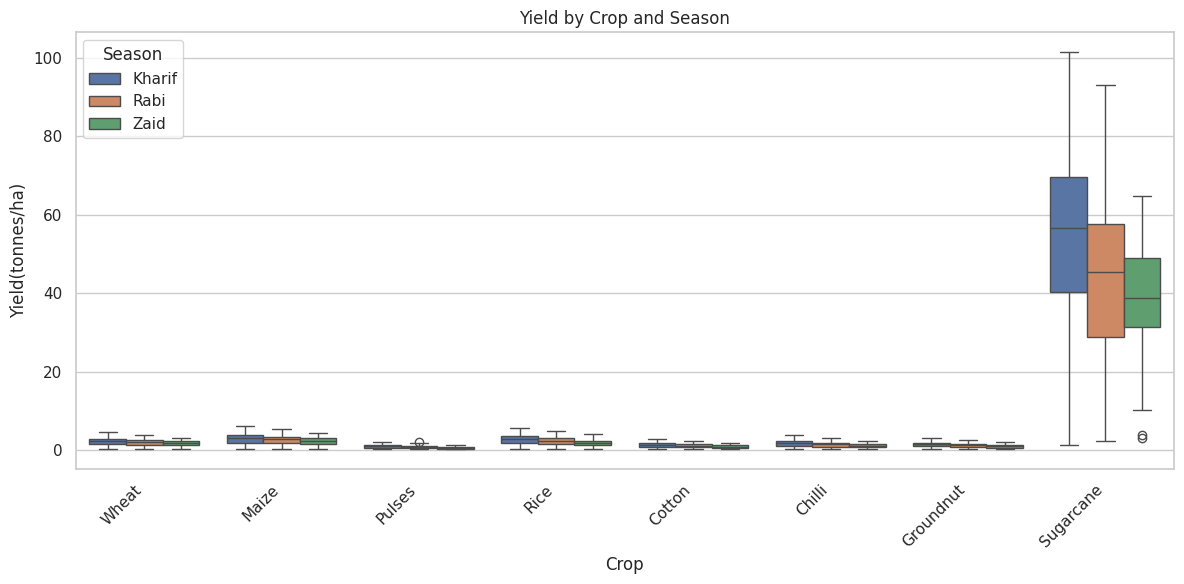

In [52]:
# Multivariate: Season, crop and yield

plt.figure(figsize= (12,6))
sns.boxplot(data=df, x="Crop", y="Yield_Tonnes_Ha", hue="Season")
plt.xticks(rotation=45, ha="right")
plt.title("Yield by Crop and Season")
plt.xlabel("Crop")
plt.ylabel("Yield(tonnes/ha)")
plt.legend(title="Season")
plt.tight_layout()
plt.show()

##Multivariate: Pair Plot of Key Enviromental and Performance Metrics by Season

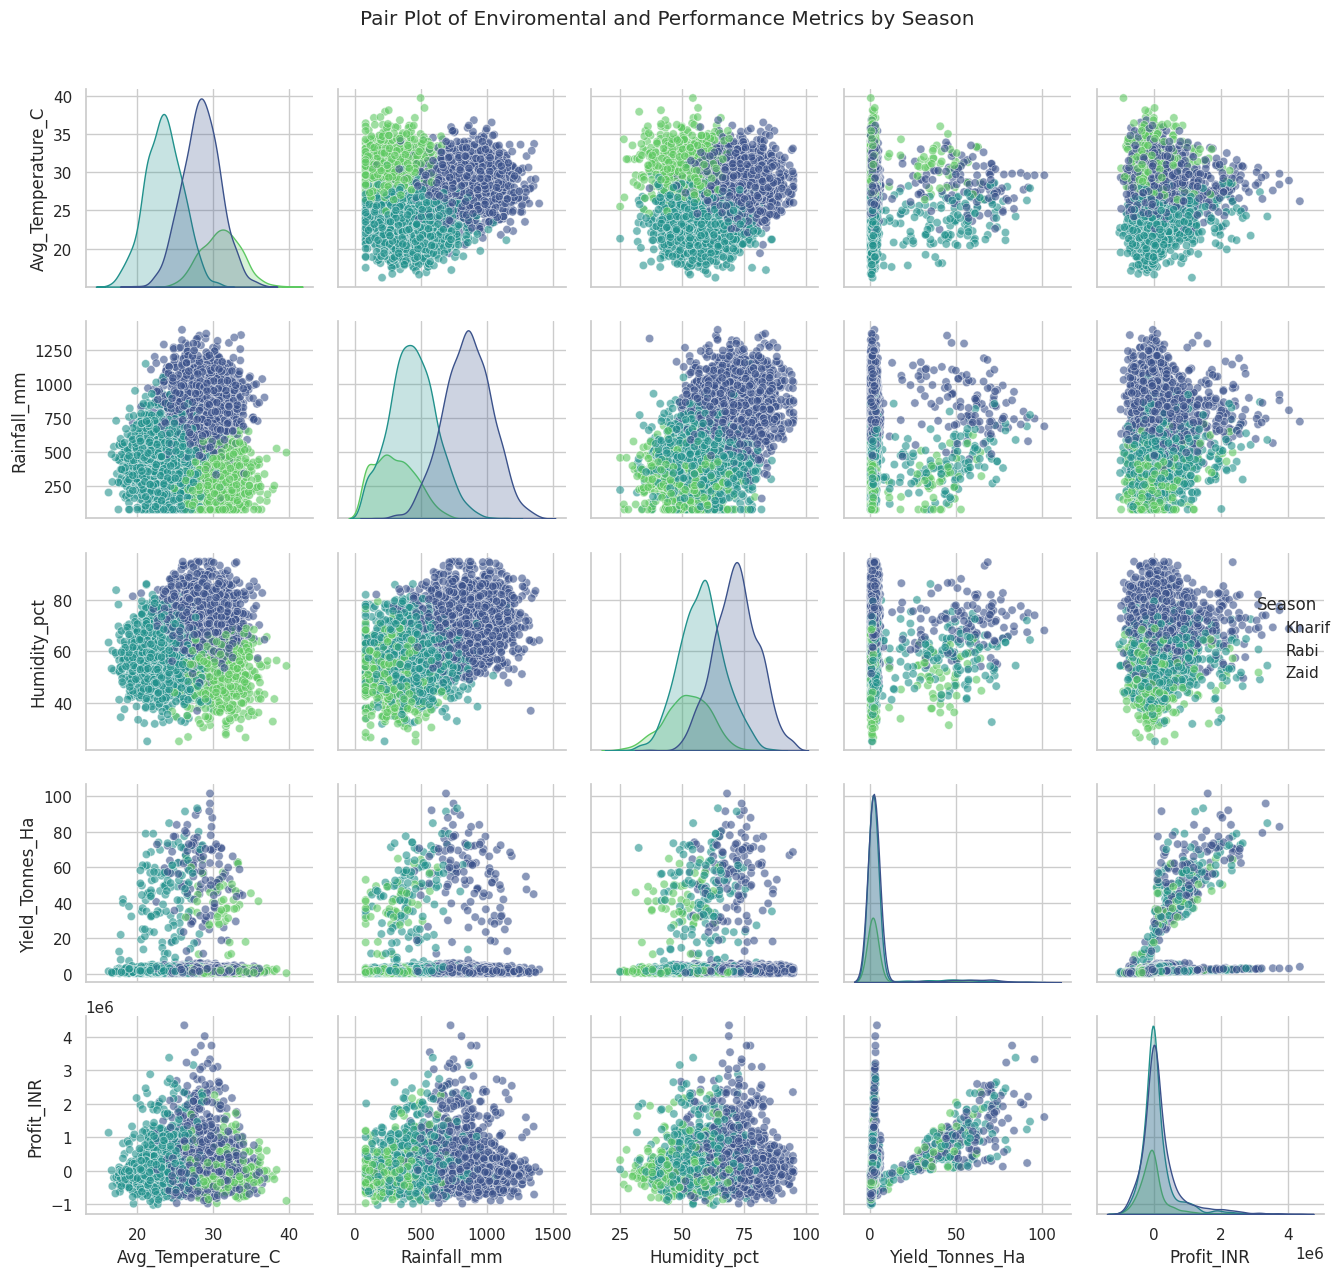

In [62]:
selected_columns= ['Avg_Temperature_C', 'Rainfall_mm', 'Humidity_pct', 'Yield_Tonnes_Ha', 'Profit_INR', 'Season']
sns.pairplot(df[selected_columns], hue="Season", palette='viridis', plot_kws={'alpha':0.6})
plt.suptitle("Pair Plot of Enviromental and Performance Metrics by Season", y=1.02) #Adjust suptitle position
plt.tight_layout()
plt.show()

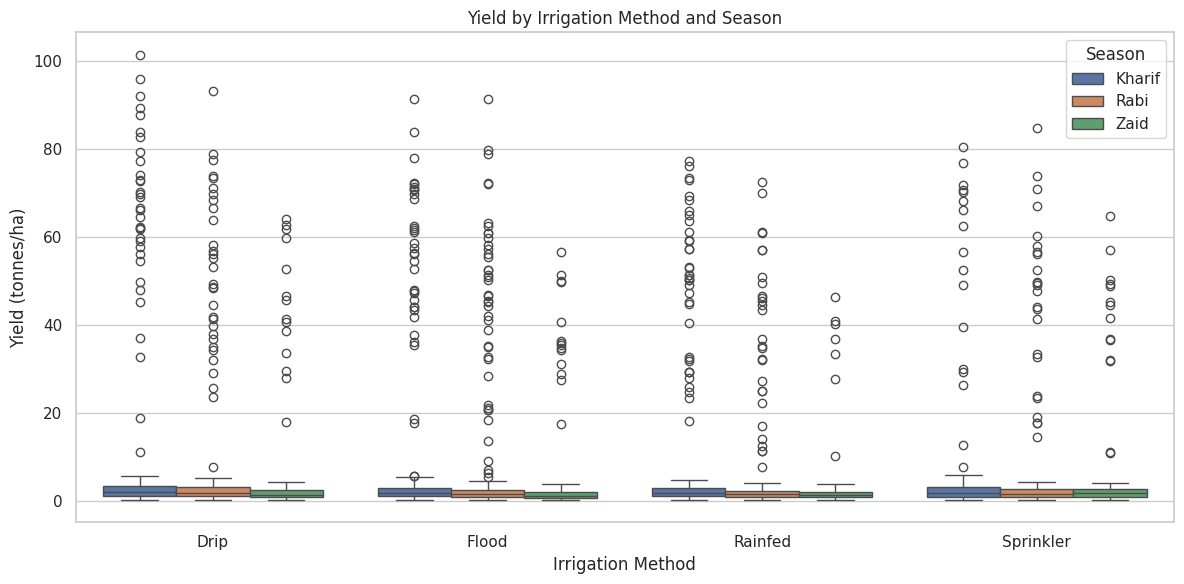

In [63]:
#Multivariate: Season, irrigation and yield

plt.figure(figsize=(12,6))
sns.boxplot(data=df, x="Irrigation_Method", y="Yield_Tonnes_Ha", hue="Season")
plt.title("Yield by Irrigation Method and Season")
plt.xlabel("Irrigation Method")
plt.ylabel("Yield (tonnes/ha)")
plt.legend(title="Season")
plt.tight_layout()
plt. show()

<function matplotlib.pyplot.show(close=None, block=None)>

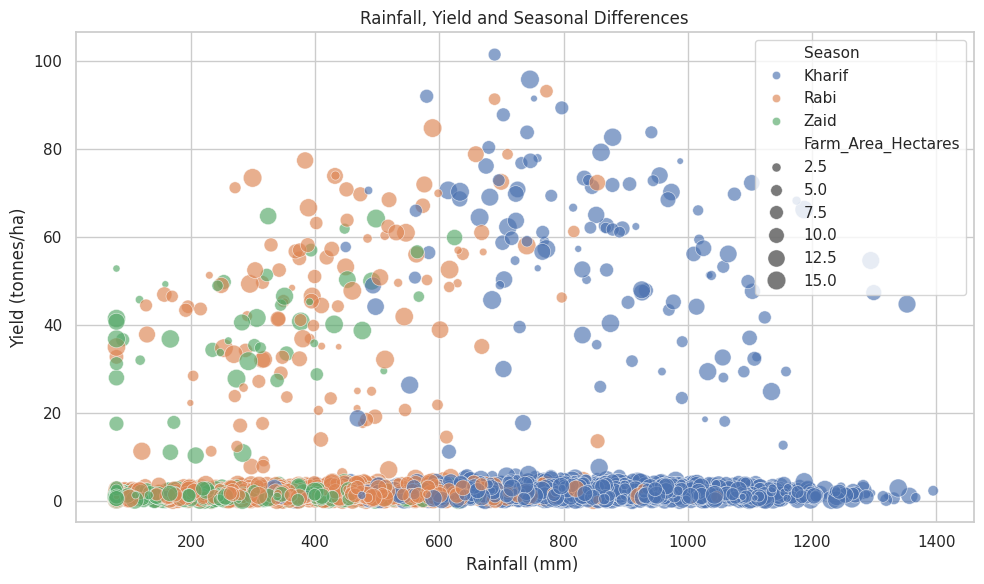

In [64]:
# Multivariate: Rainfall, yield and season
plt.figure(figsize=(10, 6))
sns.scatterplot(
data=df,
x="Rainfall_mm",
y="Yield_Tonnes_Ha",
hue="Season",
size="Farm_Area_Hectares",
sizes=(20, 180),
alpha=0.65
)
plt. title("Rainfall, Yield and Seasonal Differences")
plt.xlabel("Rainfall (mm) ")
plt.ylabel("Yield (tonnes/ha)")
plt.tight_layout()
plt.show

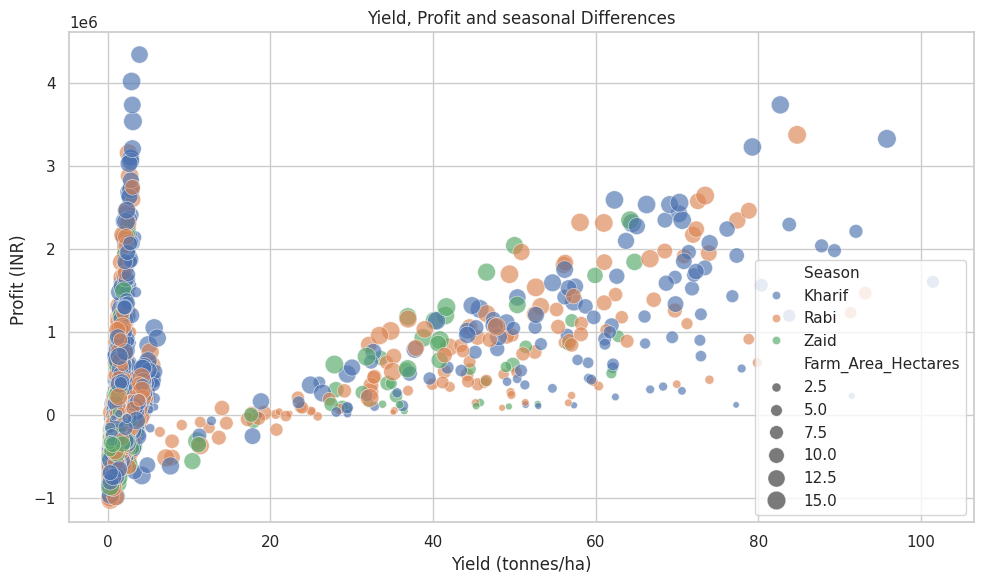

In [72]:
# Multivariate: Profit, yield and season
plt.figure(figsize=(10, 6))
sns.scatterplot(
data=df,
x= "Yield_Tonnes_Ha",
y="Profit_INR",
hue="Season",
size="Farm_Area_Hectares",
sizes= (20, 180),
alpha=0.65
)
plt.title("Yield, Profit and seasonal Differences")
plt.xlabel("Yield (tonnes/ha)")
plt.ylabel ("Profit (INR) ")
plt.tight_layout()
plt.show()

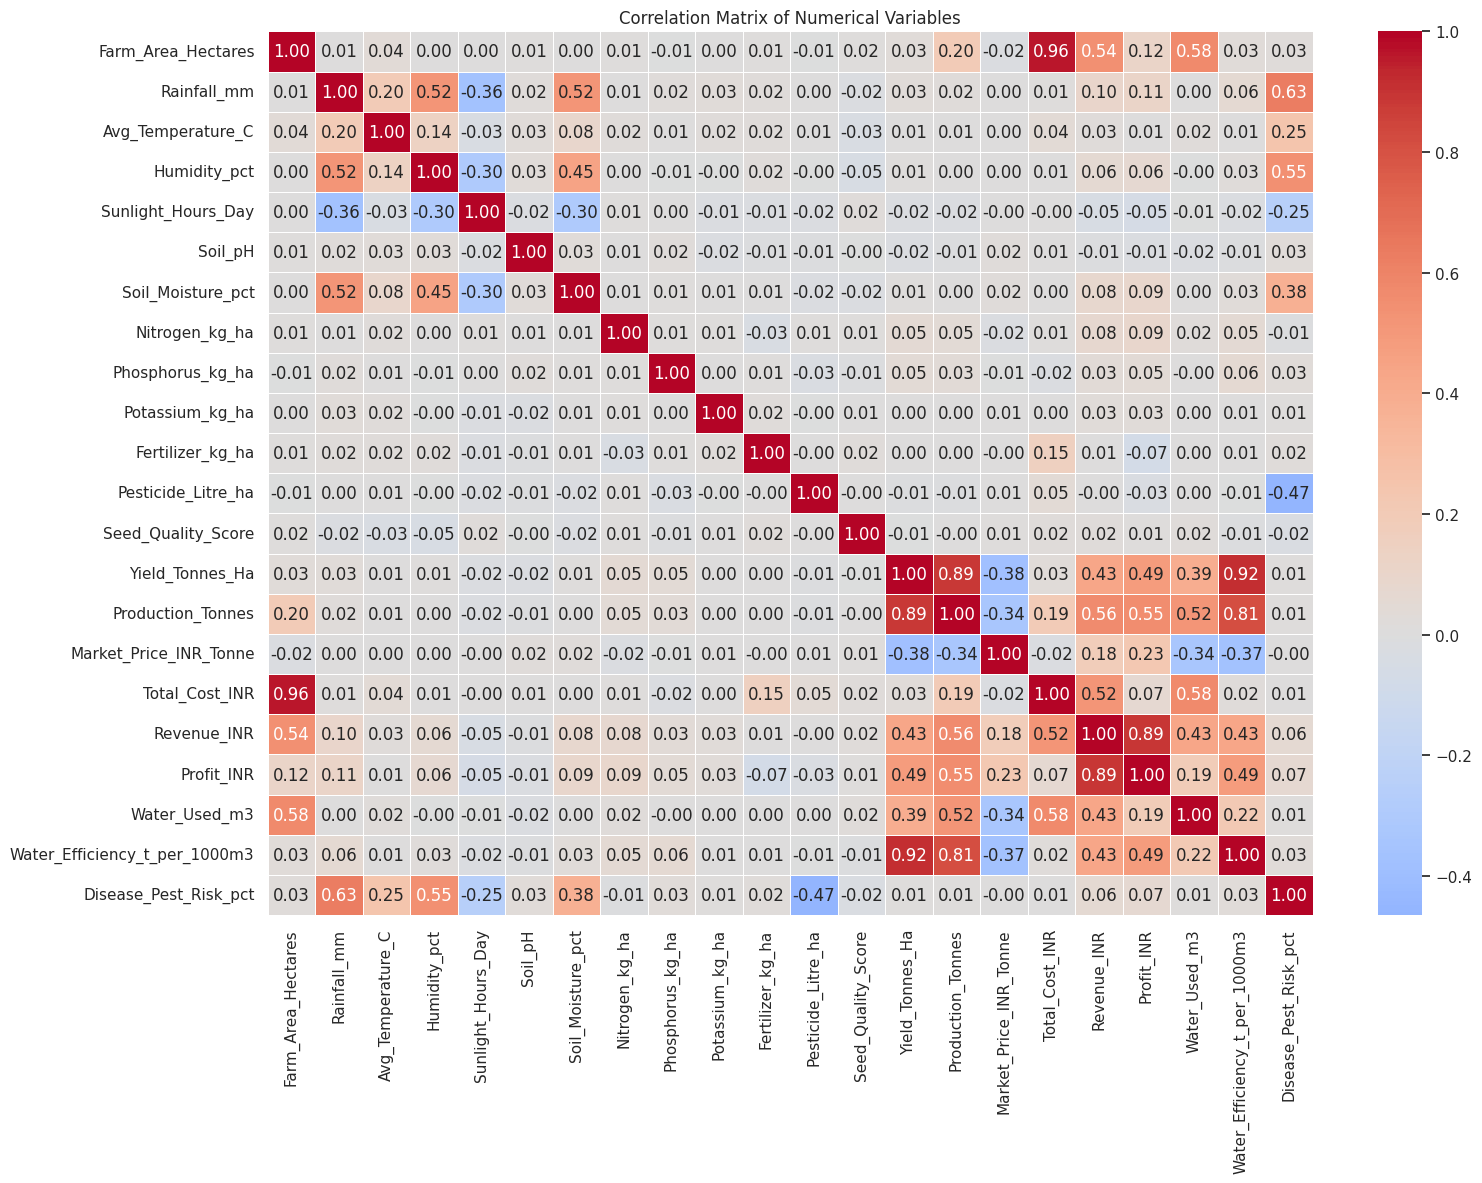

In [74]:
#Correlation heatmap for numerical variables

plt. figure(figsize=(16, 12))
corr=df[numeric_columns].corr(numeric_only=True)

sns.heatmap(
corr,
annot=True,
fmt=".2f",
cmap="coolwarm",
center=0,
linewidths=0.5
)
plt.title("Correlation Matrix of Numerical Variables")
plt.tight_layout()
plt.show()

##13. Seasonal Comparison

In [83]:
# General seasonal summary

season_metrics = df.groupby("Season").agg(
 Records= ("Farm_ID","count"),
 Average_Yield=("Yield_Tonnes_Ha", "mean"),
 Total_Production=("Production_Tonnes","sum"),
 Average_Profit=("Profit_INR", "mean"),
 Total_Profit= ("Profit_INR","sum"),
 Average_Water_Used=("Water_Used_m3", "mean")
 ) .round(2)
season_metrics

,Records,Average_Yield,Total_Production,Average_Profit,Total_Profit,Average_Water_Used
Season,,,,,,
Kharif,1779,5.64,"82,387.61","178,914.65",318289158,"6,102.20"
Rabi,1627,5.08,"67,498.88","87,689.47",142670768,"5,846.99"
Zaid,594,4.67,"23,098.35","-24,804.82",-14734066,"6,419.89"


In [91]:
#Compare crop performance within each season

crop_season_summary =(
    df.groupby(["Season", "Crop"])
    .agg(
        Average_Yield=("Yield_Tonnes_Ha","mean"),
        Average_Profit=("Profit_INR", "mean"),
        Average_water_Efficiency=("Water_Efficiency_t_per_1000m3", "mean")
)
.round(2)
 .sort_values(["Season","Average_Yield"], ascending=[True, False])
)
crop_season_summary

Average_Yield  Average_Profit  Average_water_Efficiency
Season Crop                                                              
Kharif Sugarcane          53.46    1,000,790.81                     36.00
       Maize               2.97      -39,332.67                      6.05
       Rice                2.71      -64,903.40                      2.17
       Wheat               2.26     -105,871.87                      4.76
       Chilli              1.73      954,380.42                      3.26
       Groundnut           1.48      108,265.44                      3.58
       Cotton              1.37      216,999.55                      2.13
       Pulses              1.04       43,338.90                      3.35
Rabi   Sugarcane          43.94      731,612.86                     27.92
       Maize               2.61      -89,133.40                      5.46
       Rice                2.33      -98,427.87                      1.84
       Wheat               2.06     -119,954.57                      4.69
       Chilli              1.46      638,572.50                      2.89
       Groundnut           1.22       10,416.54                      2.90
       Cotton              1.19      107,343.59                      1.94
       Pulses              0.87      -14,309.14                      2.70
Zaid   Sugarcane          38.42      583,635.80                     23.39
       Maize               2.30     -194,049.17                      4.75
       Rice                1.90     -227,239.34                      1.53
       Wheat               1.75     -193,208.95                      4.02
       Chilli              1.18      448,659.09                      2.20
       Groundnut           1.04      -68,872.50                      2.47
       Cotton              0.95      -53,925.34                      1.49
       Pulses              0.65     -139,227.81                      1.95

## 13. Student-Designed Analyses

The four analyses below go beyond the standard workflow and were designed independently for this project to dig deeper into *why* seasonal performance differs.

In [92]:
### 13.1 Crop × Season Profitability Matrix
df['Profit_Margin_pct'] = (df['Profit_INR'] / df['Revenue_INR'].replace(0, np.nan)) * 100

profit_matrix = df.pivot_table(index='Crop', columns='Season', values='Profit_INR', aggfunc='mean').reindex(columns=season_order)
margin_matrix = df.pivot_table(index='Crop', columns='Season', values='Profit_Margin_pct', aggfunc='mean').reindex(columns=season_order)

print("Average Profit (INR/farm) by Crop and Season:")
display(profit_matrix.round(0))
print()
print("Average Profit Margin (%) by Crop and Season:")
display(margin_matrix.round(1))

Average Profit (INR/farm) by Crop and Season:


Season,Kharif,Rabi,Zaid
Crop,,,
Chilli,"954,380.00","638,572.00","448,659.00"
Cotton,"217,000.00","107,344.00","-53,925.00"
Groundnut,"108,265.00","10,417.00","-68,872.00"
Maize,"-39,333.00","-89,133.00","-194,049.00"
Pulses,"43,339.00","-14,309.00","-139,228.00"
Rice,"-64,903.00","-98,428.00","-227,239.00"
Sugarcane,"1,000,791.00","731,613.00","583,636.00"
Wheat,"-105,872.00","-119,955.00","-193,209.00"



Average Profit Margin (%) by Crop and Season:


Season,Kharif,Rabi,Zaid
Crop,,,
Chilli,40.50,31.60,20.00
Cotton,5.40,-6.60,-43.70
Groundnut,-12.60,-36.70,-59.50
Maize,-79.30,-79.50,-93.40
Pulses,-23.80,-35.80,-84.00
Rice,-93.10,-98.20,-121.90
Sugarcane,30.80,25.50,23.50
Wheat,-88.20,-82.60,-128.90


**Finding:** Chilli and Sugarcane are the **only** crops with a positive profit margin in every single season. Rice, Wheat and Maize post **negative margins in all three seasons** (as low as −128%), meaning that on average, growing these crops costs more than the revenue they generate in this dataset.

In [ ]:
### 13.2 Irrigation Method Efficiency Analysis

In [93]:
irr_summary = df.groupby('Irrigation_Method')[['Water_Used_m3', 'Yield_Tonnes_Ha',
                                                 'Water_Efficiency_t_per_1000m3', 'Profit_INR']].mean().round(2)
irr_summary = irr_summary.sort_values('Water_Efficiency_t_per_1000m3', ascending=False)
irr_summary

,Water_Used_m3,Yield_Tonnes_Ha,Water_Efficiency_t_per_1000m3,Profit_INR
Irrigation_Method,,,,
Rainfed,"3,549.55",4.61,7.56,"79,050.37"
Drip,"5,918.75",6.62,6.27,"219,626.00"
Sprinkler,"6,208.26",5.19,4.67,"91,121.08"
Flood,"8,026.47",4.90,3.44,"73,354.02"


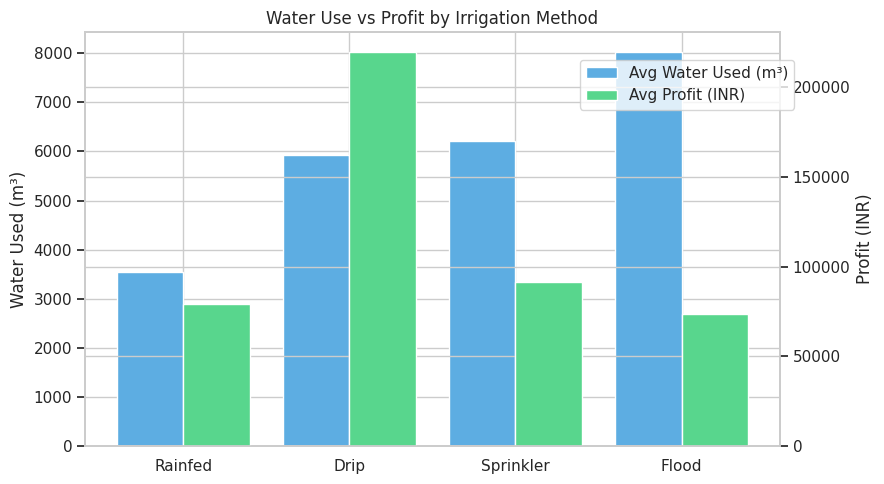

In [94]:
fig, ax1 = plt.subplots(figsize=(9, 5))
x = np.arange(len(irr_summary))
ax1.bar(x - 0.2, irr_summary['Water_Used_m3'], width=0.4, label='Avg Water Used (m³)', color='#5dade2')
ax1.set_ylabel('Water Used (m³)')
ax2 = ax1.twinx()
ax2.bar(x + 0.2, irr_summary['Profit_INR'], width=0.4, label='Avg Profit (INR)', color='#58d68d')
ax2.set_ylabel('Profit (INR)')
ax1.set_xticks(x)
ax1.set_xticklabels(irr_summary.index)
ax1.set_title('Water Use vs Profit by Irrigation Method')
fig.legend(loc='upper right', bbox_to_anchor=(0.9, 0.88))
plt.tight_layout()
plt.show()

**Finding:** Drip irrigation delivers the highest yield and highest average profit while using *less* water than Flood irrigation. Flood irrigation uses the most water of any method yet produces the lowest water efficiency and among the lowest profit — a clear efficiency gap.

In [ ]:
### 13.3 Disease/Pest Risk Impact Analysis

In [95]:
df['Risk_Level'] = pd.qcut(df['Disease_Pest_Risk_pct'], 4, labels=['Low', 'Moderate', 'High', 'Very High'])
risk_summary = df.groupby('Risk_Level')[['Yield_Tonnes_Ha', 'Profit_INR', 'Pesticide_Litre_ha']].mean().round(2)
risk_summary

/tmp/ipykernel_3534/1078308733.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  risk_summary = df.groupby('Risk_Level')[['Yield_Tonnes_Ha', 'Profit_INR', 'Pesticide_Litre_ha']].mean().round(2)


,Yield_Tonnes_Ha,Profit_INR,Pesticide_Litre_ha
Risk_Level,,,
Low,4.97,"34,057.81",6.31
Moderate,5.13,"117,270.76",5.18
High,5.88,"157,388.28",4.82
Very High,5.11,"138,680.23",3.96


/tmp/ipykernel_3534/3813718307.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Risk_Level', y='Yield_Tonnes_Ha', ax=axes[0], palette='OrRd')
/tmp/ipykernel_3534/3813718307.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Risk_Level', y='Profit_INR', ax=axes[1], palette='OrRd')


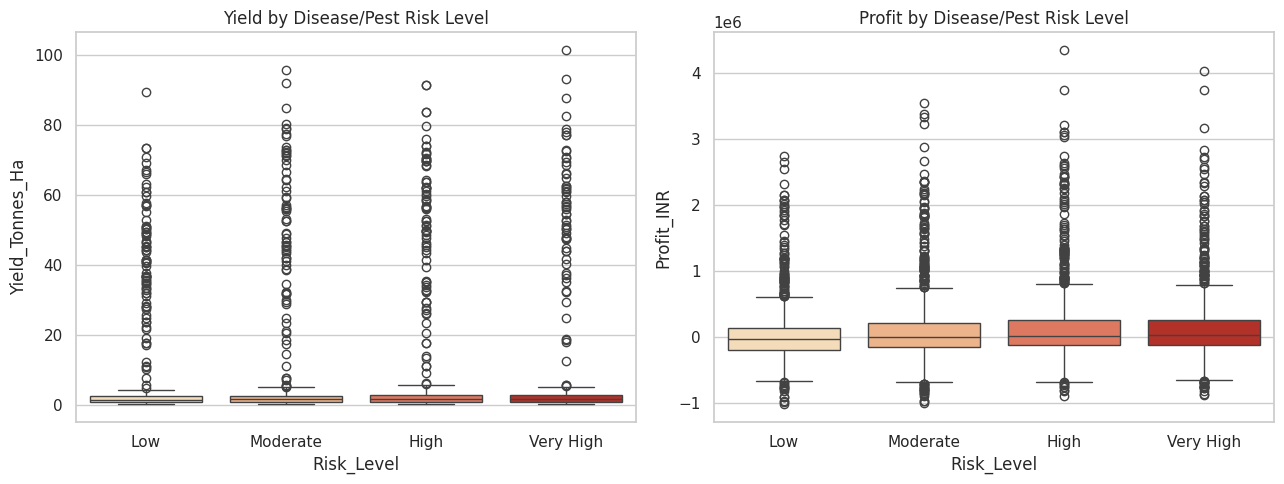

Correlation — Disease/Pest Risk vs Yield: 0.013
Correlation — Disease/Pest Risk vs Profit: 0.068


In [96]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.boxplot(data=df, x='Risk_Level', y='Yield_Tonnes_Ha', ax=axes[0], palette='OrRd')
axes[0].set_title('Yield by Disease/Pest Risk Level')
sns.boxplot(data=df, x='Risk_Level', y='Profit_INR', ax=axes[1], palette='OrRd')
axes[1].set_title('Profit by Disease/Pest Risk Level')
plt.tight_layout()
plt.show()

print("Correlation — Disease/Pest Risk vs Yield:", round(df['Disease_Pest_Risk_pct'].corr(df['Yield_Tonnes_Ha']), 3))
print("Correlation — Disease/Pest Risk vs Profit:", round(df['Disease_Pest_Risk_pct'].corr(df['Profit_INR']), 3))

**Finding (unexpected pattern):** Farms in the 'Very High' disease/pest risk group do **not** show meaningfully lower yield or profit than 'Low' risk farms — the correlation is close to zero. This is counter-intuitive and suggests either the risk score is not capturing realized crop damage, or pesticide application is already compensating for higher risk before it affects output.

### 13.4 State-wise Seasonal Performance Ranking

In [97]:
state_season_profit = df.pivot_table(index='State', columns='Season', values='Profit_INR', aggfunc='mean').reindex(columns=season_order)
state_season_profit['Overall_Avg'] = df.groupby('State')['Profit_INR'].mean()
state_season_profit = state_season_profit.sort_values('Overall_Avg', ascending=False).round(0)
state_season_profit

Season,Kharif,Rabi,Zaid,Overall_Avg
State,,,,
Punjab,"133,779.00","169,295.00","62,110.00","136,026.00"
Maharashtra,"168,801.00","159,582.00","-40,598.00","135,429.00"
Karnataka,"201,226.00","70,953.00","23,311.00","119,422.00"
Tamil Nadu,"211,304.00","70,457.00","-15,175.00","117,745.00"
Gujarat,"217,051.00","82,846.00","-106,930.00","117,568.00"
Telangana,"199,668.00","62,825.00","-34,621.00","108,830.00"
Madhya Pradesh,"134,242.00","61,576.00",210.00,"86,841.00"
Andhra Pradesh,"169,316.00","26,316.00","-84,085.00","73,454.00"


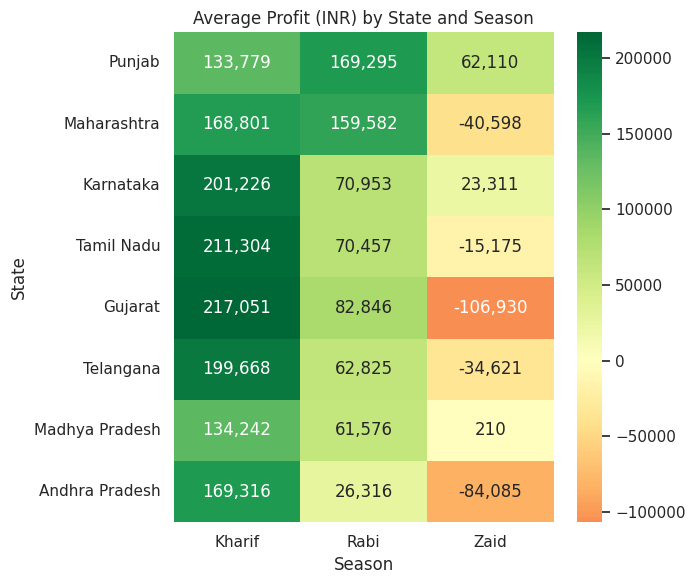

In [98]:
plt.figure(figsize=(7, 6))
sns.heatmap(state_season_profit.drop(columns='Overall_Avg'), annot=True, fmt=',.0f', cmap='RdYlGn', center=0)
plt.title('Average Profit (INR) by State and Season')
plt.tight_layout()
plt.show()

**Finding:** Punjab and Maharashtra are the most consistently profitable states overall; Andhra Pradesh ranks lowest. Punjab is the *only* state that stays profitable even in Zaid, while most other states swing to a loss in that season — rankings clearly shift by season, not just by state.

## 14. Key Insights

1. **Crop type, not season, is the dominant driver of yield.** ANOVA shows yield differences across seasons are *not* statistically significant (p ≈ 0.23), while yield varies by nearly 50× across crops (Sugarcane ≈ 47 t/ha vs Pulses ≈ 0.9 t/ha).
2. **Season strongly affects profitability**, even though it barely affects yield. Average profit is highest in Kharif (≈ ₹1.79 lakh/farm), moderate in Rabi (≈ ₹0.88 lakh), and turns **negative** in Zaid (≈ −₹0.25 lakh) — a statistically significant difference (p < 0.0001).
3. **Zaid (summer) season is loss-making for most crops and states.** Only Chilli, Sugarcane, and farms in Punjab/Karnataka/Madhya Pradesh stay profitable in Zaid; the rest turn negative.
4. **Rice, Wheat and Maize run a structural loss in every season** in this dataset (margins from −79% to −128%), while **Chilli and Sugarcane are consistently the most profitable crops** (margins of 20–40% in every season).
5. **Global outlier detection is misleading for this dataset.** 302 of 4,000 yield records look like statistical outliers under one dataset-wide IQR rule, but a per-crop check shows they are simply all Sugarcane farms — a genuinely high-yielding crop, not data errors.
6. **Agronomic inputs show almost no correlation with yield.** Fertilizer, pesticide dose and seed quality score all have |r| < 0.06 with yield — even within individual crops — suggesting yield here is explained far more by crop choice and water-use efficiency (r ≈ 0.92) than by input intensity.
7. **Drip irrigation is the most efficient and most profitable irrigation method** (highest yield and highest average profit), while **Flood irrigation consumes the most water for the lowest returns** — a clear inefficiency gap.
8. **Disease/pest risk shows almost no measurable relationship with yield or profit** (r ≈ 0.01–0.07) — an unexpected pattern that is worth flagging as either effective pest management or a limitation of the risk metric itself.
9. **Kharif carries the highest average disease/pest risk (≈ 54.5%) and highest rainfall (≈ 852 mm)**, consistent with monsoon-season humidity; **Zaid has the lowest of both (≈ 38.2% risk, ≈ 299 mm rainfall)**.
10. **State performance rankings shift by season.** Gujarat and Tamil Nadu lead in Kharif but fall into losses in Zaid, while Punjab overtakes them in Zaid — a single "best state" ranking hides important seasonal reversals.
11. **Missing data is small and evenly spread** (each affected column < 1.5% of records, proportionally distributed across seasons/crops) — consistent with data missing completely at random, supporting the median-imputation approach used in Section 4.